In [1]:
import numpy as np
from raftup import (
    _downsample,
    _fsgw_utils,
    _metrics_two_gpr,
    _load_data,
    _plot
)

/opt/anaconda3/envs/raftup_env/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/opt/anaconda3/envs/raftup_env/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
section_ids_list = [['-0.14', '-0.19']]
pair = "m0p14_m019"
ds_pts = 200

for section_ids in section_ids_list:
    dataset = section_ids[0] + '_' + section_ids[1]

    sliceA = _load_data.load_mHypothalamus(section_id=section_ids[0])
    sliceB = _load_data.load_mHypothalamus(section_id=section_ids[1])

    coordsA = sliceA.obsm["spatial"]
    coordsB = sliceB.obsm["spatial"]

    print(f"Slice {section_ids[0]} x-range: {coordsA[:,0].min():.1f} ~ {coordsA[:,0].max():.1f}")
    print(f"Slice {section_ids[0]} y-range: {coordsA[:,1].min():.1f} ~ {coordsA[:,1].max():.1f}")
    print(f"Slice {section_ids[1]} x-range: {coordsB[:,0].min():.1f} ~ {coordsB[:,0].max():.1f}")
    print(f"Slice {section_ids[1]} y-range: {coordsB[:,1].min():.1f} ~ {coordsB[:,1].max():.1f}")

/opt/anaconda3/envs/raftup_env/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Slice -0.14 x-range: -2926.8 ~ -1134.4
Slice -0.14 y-range: -650.8 ~ 1140.4
Slice -0.19 x-range: 1148.3 ~ 2937.8
Slice -0.19 y-range: -867.2 ~ 923.7


/opt/anaconda3/envs/raftup_env/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [3]:
# Slice -0.14 x-range: -2926.8 ~ -1134.4
# Slice -0.14 y-range: -650.8 ~ 1140.4
# Slice -0.19 x-range: 1148.3 ~ 2937.8
# Slice -0.19 y-range: -867.2 ~ 923.7

import scanpy as sc

rect_bounds_A = (-2200.0, -1900.0, -700.0, -220.0)  # (xmin, xmax, ymin, ymax)

subA, idxA = _downsample.downsample_slice_by_window(
    sliceA,
    rect_bounds=rect_bounds_A,
    max_points=ds_pts,   
    strict=False,        
    coord_key="spatial",
)


rect_bounds_B = (1850.0, 2080.0, -750.0, -400.0)
subB, idxB = _downsample.downsample_slice_by_window(
    sliceB,
    rect_bounds=rect_bounds_B,
    max_points=ds_pts,
    strict=False,
    coord_key="spatial",
)

print(subA.shape, subB.shape)


[downsample_slice_by_window] Sub-slice contains 251 points in window (-2200.0, -1900.0, -700.0, -220.0)
→ Truncated to 200 points (strict=False).
[downsample_slice_by_window] Sub-slice contains 203 points in window (1850.0, 2080.0, -750.0, -400.0)
→ Truncated to 200 points (strict=False).
(200, 155) (200, 155)


/Users/salovjade/Library/CloudStorage/Dropbox/raftup_repo/src/raftup/_downsample.py:112: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if coord_key not in sliceA.obsm_keys():


In [4]:

import scanpy as sc
from sklearn.metrics import pairwise_distances

common = subA.var_names.intersection(subB.var_names)
a1 = subA[:, common].copy()
a2 = subB[:, common].copy()

sc.pp.normalize_total(a1, target_sum=1e4); sc.pp.log1p(a1)
sc.pp.normalize_total(a2, target_sum=1e4); sc.pp.log1p(a2)


a = a1.concatenate(a2, batch_key="batch", batch_categories=["a1","a2"])

sc.pp.scale(a, max_value=10)     
sc.tl.pca(a, n_comps=50)


Z = a.obsm["X_pca"]
Z1 = Z[a.obs["batch"] == "a1"]
Z2 = Z[a.obs["batch"] == "a2"]

M_pca = pairwise_distances(Z1, Z2, metric="euclidean")
print(M_pca.shape)


(200, 200)


/var/folders/dj/6qv7h1l52bvgckcytvzh5ws00000gn/T/ipykernel_65567/3470003819.py:12: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  a = a1.concatenate(a2, batch_key="batch", batch_categories=["a1","a2"])


In [5]:
from scipy.spatial import distance

D_A_test = distance.cdist(subA.obsm['spatial'], subA.obsm['spatial'])
D_B_test = distance.cdist(subB.obsm['spatial'], subB.obsm['spatial'])

testA = D_A_test[D_A_test>0]
testB = D_B_test[D_B_test>0]
print(np.min(testA), np.min(testB))

2.5507778840314446 5.63593906335937


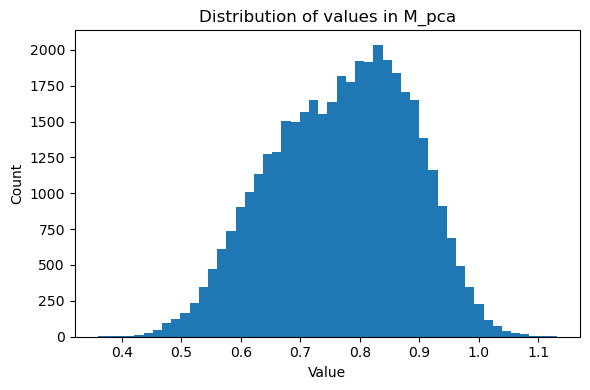

In [6]:
import numpy as np
import matplotlib.pyplot as plt

p99_pca = np.percentile(M_pca[M_pca > 0], 99)
M_norm_pca = M_pca / (p99_pca + 1e-12)


# M: (n1, n2) matrix
vals = M_norm_pca.flatten()

plt.figure(figsize=(6, 4))
plt.hist(vals, bins=50) 
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Distribution of values in M_pca")
plt.tight_layout()
plt.show()

In [7]:
import numpy as np
from pathlib import Path
from tqdm import tqdm


# ======================
# Paths (DO NOT depend on cwd)
# ======================

from pathlib import Path

try:
    ROOT = Path(__file__).resolve().parents[1]
except NameError:
    # __file__ not defined (e.g. in Jupyter)
    ROOT = Path.cwd()

SAVE_DIR = ROOT / "outputs" / "align_data"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

ROOT = Path(".").resolve()   # 当前 notebook / script 所在目录
DATA_DIR = ROOT              # h5ad 在当前目录
OUTPUT_DIR = ROOT / "outputs" / "align_data"


In [8]:
# ======================
# Parameters
# ======================
cutoff_GW_list = [25]
cutoff_CC_list = [0.55]


# ======================
# Main loop
# ======================
for cutoff_GW in cutoff_GW_list:
    for cutoff_CC in cutoff_CC_list:

        print(f"\nRunning ds with GW cutoff = {cutoff_GW}, CC cutoff = {cutoff_CC}")

        P = _fsgw_utils.fsgw_mvc_exp(
            D_A_test,
            D_B_test,
            M_norm_pca,
            gw_cutoff=cutoff_GW,
            w_cutoff=cutoff_CC
        )

        print("P.sum():", P.sum())

        test_label_full = np.concatenate(
            (
                np.array(subA.obs["original_clusters"]),
                np.array(subB.obs["original_clusters"]),
            ),
            axis=0,
        )

        XA_full = subA.obsm["spatial"]
        XB_full = subB.obsm["spatial"]

        full_window_LAA = _metrics_two_gpr.cal_layer_based_alignment_result_merfish_skill_all_zero(
            P, test_label_full
        )

        full_window_GPR_15 = _metrics_two_gpr.GPR_original(
            P, XA_full, XB_full, dis_cut=15, P_cut=1e-20
        )
        full_window_GPR_30 = _metrics_two_gpr.GPR_original(
            P, XA_full, XB_full, dis_cut=30, P_cut=1e-20
        )
        full_window_GPR_45 = _metrics_two_gpr.GPR_original(
            P, XA_full, XB_full, dis_cut=45, P_cut=1e-20
        )

        print(f"full_raftup_LAA merfish window", full_window_LAA)
        print("full_window_GPR_15:", full_window_GPR_15)
        print("full_window_GPR_30:", full_window_GPR_30)
        print("full_window_GPR_45:", full_window_GPR_45)
        print("---------------------------------------------------------------")

        save_path = SAVE_DIR / (
            f"ds_matching_overlapping_window_"
            f"GW{cutoff_GW}_CC{cutoff_CC}_MERFISH_window_pca.npy"
        )

        np.save(save_path, P)
        print(f"Saved to: {save_path}")


Running ds with GW cutoff = 25, CC cutoff = 0.55


sOT Iterations: 100%|██████████| 10000/10000 [00:02<00:00, 3866.37it/s]


P.sum(): 0.2649999999999886
full_raftup_LAA merfish window 0.8245614035087719
full_window_GPR_15: 0.8826309442404325
full_window_GPR_30: 0.8333442050696245
full_window_GPR_45: 0.874974578753561
---------------------------------------------------------------
Saved to: /Users/salovjade/Library/CloudStorage/Dropbox/RAFTUP_after0320/raftup_reproduce/synthetic_window/0.14-0.19_window/outputs/align_data/ds_matching_overlapping_window_GW25_CC0.55_MERFISH_window_pca.npy


In [9]:
import numpy as np

def compute_rigid_transform(A, B, allow_reflection=False, force_reflection=False):
    """
    Compute rigid transform (R, t) that best aligns A to B in least squares sense:
      minimize || R A_i + t - B_i ||_F

    A, B: (k, 2) or (k, 3) arrays of matched points
    Returns
    -------
    R : (d, d)  rotation / reflection matrix (orthogonal)
    t : (d,)    translation vector

    Parameters
    ----------
    allow_reflection : bool, default False
        If False, we enforce det(R) > 0 (pure rotation, no reflection).
        If True, we accept det(R) < 0 (reflection allowed).

    force_reflection : bool, default False
        If True, we try to make det(R) < 0 (i.e., include a reflection).
        This is applied after the initial SVD.
    """
    A = np.asarray(A, float)
    B = np.asarray(B, float)
    assert A.shape == B.shape
    d = A.shape[1]

    # 1) subtract centroids
    centroid_A = A.mean(axis=0)
    centroid_B = B.mean(axis=0)
    AA = A - centroid_A
    BB = B - centroid_B

    # 2) SVD on covariance
    H = AA.T @ BB
    U, S, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T

    detR = np.linalg.det(R)

    # 3a) 默认：不允许 reflection，就把 det(R) 调成正的（和你原来代码一样）
    if (not allow_reflection) and detR < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T
        detR = np.linalg.det(R)

    # 3b) 如果想强制 reflection（det<0），就再反一列
    if force_reflection and detR > 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T
        detR = np.linalg.det(R)

    # 4) translation
    t = centroid_B - R @ centroid_A

    return R, t

adata_1 = subA
adata_2 = subB

P_path = OUTPUT_DIR / "ds_matching_overlapping_window_GW25_CC0.55_MERFISH_window_pca.npy"
P_raftup_window = np.load(P_path)

X1 = adata_1.obsm['spatial']
X2 = adata_2.obsm['spatial']

# use hard matches: j_star = argmax_j P[i,j]
j_star = P_raftup_window.argmax(axis=1)                  
# 只保留那些确实有非零质量的 i
valid_i = np.where(P_raftup_window.max(axis=1) > 1e-20)[0]
matched_i = valid_i
matched_j = j_star[valid_i]

A = X1[matched_i]       # (k, 2)
B = X2[matched_j]       # (k, 2)

#R, t = compute_rigid_transform(A, B)

R, t = compute_rigid_transform(A, B, allow_reflection=True)

#R, t = compute_rigid_transform(A, B, allow_reflection=True, force_reflection=True)

# apply to ALL points in slice A (or B, depending which you want to move)
X1_aligned_direct = (X1 @ R.T) + t  # (n1, 2)

In [10]:
import numpy as np
import scanpy as sc
from pathlib import Path

from raftup._plot import visualize_ot_mapping_3d


# ======================
# Helper: hex -> RGB
# ======================
def hex_to_rgb01(hex_str):
    """Convert '#RRGGBB' to (r,g,b) floats in [0,1]."""
    hex_str = hex_str.lstrip("#")
    return tuple(int(hex_str[i:i+2], 16) / 255.0 for i in (0, 2, 4))


# ======================
# Layer colors
# ======================
layer_color_hex = {
    0: "#FBB4AE",
    1: "#B3CDE3",
    2: "#CCEBC5",
    3: "#DECBE4",
    4: "#FED9A6",
    5: "#FFFFCC",
    6: "#E5D8BD",
}

layer_color = {k: hex_to_rgb01(v) for k, v in layer_color_hex.items()}


# ======================
# Load data
# ======================

l1 = adata_1.obs['original_clusters'].astype(str)
l2 = adata_2.obs['original_clusters'].astype(str)


# ======================
# Visualization
# ======================
visualize_ot_mapping_3d(
    X1_aligned_direct, X2, P_raftup_window,
    l1, l2,
    z1=0.0,
    z2=100.0,
    top_k=1,
    prob_threshold=1e-5,
    max_edges=1000,
    edge_opacity=0.15,
    edge_color=(0.3, 0.3, 0.3),
    label_colors=layer_color,
    point_size=10.0,

    # 连线粗细（Mayavi 的 tube_radius）
    edge_thickness=1.0,

    save=True,
    savename="raftup_MERFISH_small_window.png"
)


objc[65567]: Class RunLoopModeTracker is implemented in both /opt/anaconda3/envs/raftup_env/lib/libQt5Core.5.15.15.dylib (0x327929370) and /opt/anaconda3/envs/raftup_env/lib/libQt6Core.6.9.3.dylib (0x3524a95d0). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[65567]: Class QT_ROOT_LEVEL_POOL__THESE_OBJECTS_WILL_BE_RELEASED_WHEN_QAPP_GOES_OUT_OF_SCOPE is implemented in both /opt/anaconda3/envs/raftup_env/lib/libQt5Core.5.15.15.dylib (0x3279292f8) and /opt/anaconda3/envs/raftup_env/lib/libQt6Core.6.9.3.dylib (0x3524a9698). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[65567]: Class KeyValueObserver is implemented in both /opt/anaconda3/envs/raftup_env/lib/libQt5Core.5.15.15.dylib (0x327929320) and /opt/anaconda3/envs/raftup_env/lib/libQt6Core.6.9.3.dylib (0x3524a96c0). This may cause spurious casting failures and mysterious crashes. One of the 

In [11]:
P_path = OUTPUT_DIR / "ds_matching_overlapping_window_GW25_CC0.55_MERFISH_window_pca.npy"
P_raftup_window = np.load(P_path)

test_label_full = np.concatenate((np.array(adata_1.obs['original_clusters']),np.array(adata_2.obs['original_clusters'])),axis=0)
XA_full = adata_1.obsm['spatial']
XB_full = adata_2.obsm['spatial']

full_LAA = _metrics_two_gpr.cal_layer_based_alignment_result_merfish_skill_all_zero(P_raftup_window, test_label_full)
full_GPR_15= _metrics_two_gpr.GPR_original(P_raftup_window, XA_full, XB_full, dis_cut=15, P_cut=1e-20)
full_GPR_30= _metrics_two_gpr.GPR_original(P_raftup_window, XA_full, XB_full, dis_cut=30, P_cut=1e-20)
full_GPR_45= _metrics_two_gpr.GPR_original(P_raftup_window, XA_full, XB_full, dis_cut=45, P_cut=1e-20)

print(f"full_raftup_LAA for small window:", full_LAA)

print("full_raftup_GPR_15:", full_GPR_15)
print("full_raftup_GPR_30:", full_GPR_30)
print("full_raftup_GPR_45:", full_GPR_45)
print("---------------------------------------------------------------")


full_raftup_LAA for small window: 0.8245614035087719
full_raftup_GPR_15: 0.8826309442404325
full_raftup_GPR_30: 0.8333442050696245
full_raftup_GPR_45: 0.874974578753561
---------------------------------------------------------------


In [12]:
P_raftup_window.sum()

np.float64(0.2649999999999886)